# Практическая работа №5
## Моделирование сети массового обслуживания

**Тема моделирования:** пункт выдачи заказов (ПВЗ) как сеть массового обслуживания с динамически изменяющимся числом сотрудников.

В этой работе модель из прошлой лабораторной расширяется:
- вместо одной системы обслуживания используется **сеть из двух узлов**;
- у каждого узла есть **своя очередь и свои сотрудники**;
- сотрудники каждого узла могут подключаться и отключаться;
- заявки могут переходить из первого узла во второй с заданной вероятностью.

В отличие от практической работы №4, где основной акцент был на приоритетах, здесь исследуется влияние **среднего числа активных сотрудников** на характеристики сети.


## 2. Описание модели

Рассматривается сеть массового обслуживания из двух узлов.

### Узел 1
Основная выдача заказа.  
В этот узел поступают все клиенты.

### Узел 2
Дополнительная операция: возврат, уточнение данных, проверка товара или проблема с заказом.  
После первого узла клиент переходит во второй узел с вероятностью:

$$
p_{12} = p.
$$

Если переход не происходит, клиент покидает систему.

Схема движения заявки:

$$
\text{Вход} \rightarrow \text{Узел 1} \rightarrow
\begin{cases}
\text{Узел 2} \rightarrow \text{Выход}, & p \\
\text{Выход}, & 1-p
\end{cases}
$$

### Агенты

У каждого узла есть собственные агенты обслуживания:
- в узле 1 число сотрудников меняется от 2 до 4;
- в узле 2 число сотрудников меняется от 1 до 2.

В сумме по сети активных сотрудников может быть от 3 до 6.

Подключение сотрудников происходит с интенсивностью $\alpha$, отключение — с интенсивностью $\beta$.

Очереди считаются **неограниченными**, поэтому вероятность потери заявок равна нулю.


In [1]:
try:
    import simpy
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'simpy'])
    import simpy

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Фиксируемые показатели

Согласно условию работы фиксируются следующие показатели:

1. **Среднее время пребывания заявки в сети**:
$$
W = \frac{1}{N_{out}} \sum_{i=1}^{N_{out}} (t_i^{out} - t_i^{in}).
$$

2. **Среднее число заявок в очереди**:
$$
\overline{Q} = \frac{1}{T} \int_0^T Q(t)\,dt.
$$

3. **Среднее число активных агентов**:
$$
\overline{N} = \frac{1}{T} \int_0^T N(t)\,dt.
$$

4. **Вероятность потери заявок**.  
Так как очередь в данной модели не ограничена:

$$
P_{loss} = 0.
$$


## 4. Теоретическая оценка

Для теоретической оценки используется приближение через модели $M/M/c$ для каждого узла.

Интенсивность входа в первый узел:

$$
\lambda_1 = \lambda.
$$

Интенсивность входа во второй узел:

$$
\lambda_2 = \lambda p.
$$

Число агентов в каждом узле динамически меняется.  
Для узла со состояниями от $N_{min}$ до $N_{max}$ стационарные вероятности числа активных агентов:

$$
\pi_n = \frac{r^{n-N_{min}}}{\sum_{k=0}^{N_{max}-N_{min}} r^k},
\quad
r = \frac{\alpha}{\beta}.
$$

Среднее число активных агентов:

$$
\overline{N} = \sum_n n\pi_n.
$$

Для каждого фиксированного числа агентов $n$ используется формула Эрланга C для $M/M/n$.

Среднее время пребывания заявки в сети:

$$
W = W_1 + pW_2,
$$

где $W_1$ — среднее время на первом узле, $W_2$ — среднее время на втором узле.

Среднее число заявок в очереди сети:

$$
\overline{Q} = \overline{Q_1} + \overline{Q_2}.
$$


In [2]:
lambda_clients = 16       # интенсивность входящего потока клиентов
mu_service = 10           # интенсивность обслуживания одного сотрудника
p_transfer = 0.2          # вероятность перехода из узла 1 в узел 2

node1_min_agents = 2
node1_max_agents = 4

node2_min_agents = 1
node2_max_agents = 2

base_alpha = 0.9          # интенсивность подключения сотрудников
base_beta = 0.5           # интенсивность отключения сотрудников

T = 1000                  # время моделирования
n_runs = 10               # число независимых прогонов

In [3]:
def mmc_queue_metrics(lam, mu, c):
    rho = lam / (c * mu)

    if rho >= 1:
        return {
            'rho': rho,
            'P_wait': 1.0,
            'Wq': np.inf,
            'W': np.inf,
            'Q': np.inf
        }

    a = lam / mu

    sum_part = sum((a ** n) / math.factorial(n) for n in range(c))
    last_part = (a ** c) / (math.factorial(c) * (1 - rho))

    p_wait = last_part / (sum_part + last_part)
    wq = p_wait / (c * mu - lam)
    w = wq + 1 / mu
    q = lam * wq

    return {
        'rho': rho,
        'P_wait': p_wait,
        'Wq': wq,
        'W': w,
        'Q': q
    }

In [4]:
def state_probabilities(min_agents, max_agents, alpha, beta):
    states = np.arange(min_agents, max_agents + 1)
    r = alpha / beta

    weights = np.array([r ** (state - min_agents) for state in states], dtype=float)
    probabilities = weights / weights.sum()

    return states, probabilities

In [5]:
def theoretical_node_metrics(lam, mu, min_agents, max_agents, alpha, beta):
    states, probabilities = state_probabilities(min_agents, max_agents, alpha, beta)

    avg_agents = float(np.sum(states * probabilities))

    W_values = []
    Q_values = []

    for state in states:
        mmc = mmc_queue_metrics(lam, mu, int(state))
        W_values.append(mmc['W'])
        Q_values.append(mmc['Q'])

    W_avg = float(np.sum(probabilities * np.array(W_values)))
    Q_avg = float(np.sum(probabilities * np.array(Q_values)))

    return {
        'avg_agents': avg_agents,
        'W': W_avg,
        'Q': Q_avg
    }

In [6]:
def theoretical_data(lambda_clients, mu_service, p_transfer,
                     node1_min_agents, node1_max_agents,
                     node2_min_agents, node2_max_agents,
                     alpha, beta):
    node1 = theoretical_node_metrics(
        lam=lambda_clients,
        mu=mu_service,
        min_agents=node1_min_agents,
        max_agents=node1_max_agents,
        alpha=alpha,
        beta=beta
    )

    node2 = theoretical_node_metrics(
        lam=lambda_clients * p_transfer,
        mu=mu_service,
        min_agents=node2_min_agents,
        max_agents=node2_max_agents,
        alpha=alpha,
        beta=beta
    )

    return {
        'W_network_theory': node1['W'] + p_transfer * node2['W'],
        'Q_theory': node1['Q'] + node2['Q'],
        'active_agents_theory': node1['avg_agents'] + node2['avg_agents'],
        'P_loss_theory': 0.0
    }

## 5. Имитационная модель одного узла

Каждый узел сети имеет:
- собственную очередь;
- собственное число активных агентов;
- собственный процесс подключения и отключения сотрудников.

Агент не прерывает текущее обслуживание.  
Если сотрудник должен отключиться, но все сотрудники заняты, отключение произойдёт после освобождения одного из них.


In [7]:
class DynamicServiceNode:
    def __init__(self, env, name, mu_service,
                 min_agents, max_agents,
                 alpha, beta, rng):
        self.env = env
        self.name = name

        self.mu_service = mu_service
        self.min_agents = min_agents
        self.max_agents = max_agents
        self.alpha = alpha
        self.beta = beta
        self.rng = rng

        self.queue = simpy.Store(env)

        self.active_agents = min_agents
        self.available_agents = simpy.Container(env, init=min_agents, capacity=max_agents)

        self.changed = env.event()

        self.queue_samples = []
        self.active_samples = []

    def notify(self):
        if not self.changed.triggered:
            self.changed.succeed()

    def service_time(self):
        return self.rng.exponential(1 / self.mu_service)

    def request_service(self, client):
        done_event = self.env.event()

        request = {
            'client': client,
            'done_event': done_event
        }

        self.queue.put(request)
        self.notify()

        return done_event

    def dispatcher(self):
        while True:
            while self.available_agents.level >= 1 and len(self.queue.items) > 0:
                request = yield self.queue.get()

                yield self.available_agents.get(1)
                self.env.process(self.serve_request(request))

            self.changed = self.env.event()
            yield self.changed

    def serve_request(self, request):
        yield self.env.timeout(self.service_time())
        yield self.available_agents.put(1)

        request['done_event'].succeed(self.env.now)

        self.notify()

    def agent_dynamics(self):
        while True:
            next_on = self.rng.exponential(1 / self.alpha)
            next_off = self.rng.exponential(1 / self.beta)

            if next_on < next_off:
                yield self.env.timeout(next_on)

                if self.active_agents < self.max_agents:
                    self.active_agents += 1
                    yield self.available_agents.put(1)
                    self.notify()

            else:
                yield self.env.timeout(next_off)

                if self.active_agents > self.min_agents:
                    # отключается только свободный сотрудник;
                    # если свободных нет, процесс ждёт завершения обслуживания
                    yield self.available_agents.get(1)
                    self.active_agents -= 1
                    self.notify()

    def monitor(self, step=1.0):
        while True:
            self.queue_samples.append(len(self.queue.items))
            self.active_samples.append(self.active_agents)
            yield self.env.timeout(step)

## 6. Имитационная модель сети ПВЗ

Сеть состоит из двух узлов.

Все клиенты сначала проходят узел 1.  
После узла 1 клиент:
- с вероятностью $p$ переходит в узел 2;
- с вероятностью $1-p$ выходит из системы.

Время пребывания в сети считается от момента входа клиента в систему до выхода после первого или второго узла.


In [8]:
class DynamicPVZNetwork:
    def __init__(self, env, lambda_clients, mu_service, p_transfer,
                 node1_min_agents, node1_max_agents,
                 node2_min_agents, node2_max_agents,
                 alpha, beta, rng):
        self.env = env
        self.lambda_clients = lambda_clients
        self.mu_service = mu_service
        self.p_transfer = p_transfer
        self.rng = rng

        self.node1 = DynamicServiceNode(
            env=env,
            name='Выдача заказов',
            mu_service=mu_service,
            min_agents=node1_min_agents,
            max_agents=node1_max_agents,
            alpha=alpha,
            beta=beta,
            rng=rng
        )

        self.node2 = DynamicServiceNode(
            env=env,
            name='Дополнительная операция',
            mu_service=mu_service,
            min_agents=node2_min_agents,
            max_agents=node2_max_agents,
            alpha=alpha,
            beta=beta,
            rng=rng
        )

        self.arrived = 0
        self.completed = 0
        self.network_times = []

    def interarrival_time(self):
        return self.rng.exponential(1 / self.lambda_clients)

    def customer_generator(self):
        while True:
            yield self.env.timeout(self.interarrival_time())

            self.arrived += 1
            self.env.process(self.process_customer())

    def process_customer(self):
        arrival_time = self.env.now
        client = {'arrival_time': arrival_time}

        finish_node1 = yield self.node1.request_service(client)

        if self.rng.random() < self.p_transfer:
            finish_node2 = yield self.node2.request_service(client)
            finish_time = finish_node2
        else:
            finish_time = finish_node1

        self.completed += 1
        self.network_times.append(finish_time - arrival_time)

    def start(self):
        self.env.process(self.customer_generator())

        self.env.process(self.node1.dispatcher())
        self.env.process(self.node2.dispatcher())

        self.env.process(self.node1.agent_dynamics())
        self.env.process(self.node2.agent_dynamics())

        self.env.process(self.node1.monitor(step=1.0))
        self.env.process(self.node2.monitor(step=1.0))

In [9]:
def simulate_pickup_point_network(lambda_clients, mu_service, p_transfer,
                                  node1_min_agents, node1_max_agents,
                                  node2_min_agents, node2_max_agents,
                                  alpha, beta, T, seed=None):
    rng = np.random.default_rng(seed)
    env = simpy.Environment()

    network = DynamicPVZNetwork(
        env=env,
        lambda_clients=lambda_clients,
        mu_service=mu_service,
        p_transfer=p_transfer,
        node1_min_agents=node1_min_agents,
        node1_max_agents=node1_max_agents,
        node2_min_agents=node2_min_agents,
        node2_max_agents=node2_max_agents,
        alpha=alpha,
        beta=beta,
        rng=rng
    )

    network.start()
    env.run(until=T)

    q1 = np.array(network.node1.queue_samples)
    q2 = np.array(network.node2.queue_samples)

    a1 = np.array(network.node1.active_samples)
    a2 = np.array(network.node2.active_samples)

    min_len_q = min(len(q1), len(q2))
    min_len_a = min(len(a1), len(a2))

    avg_queue = float(np.mean(q1[:min_len_q] + q2[:min_len_q]))
    avg_agents = float(np.mean(a1[:min_len_a] + a2[:min_len_a]))

    return {
        'W_network_exp': float(np.mean(network.network_times)) if network.network_times else 0.0,
        'Q_exp': avg_queue,
        'active_agents_exp': avg_agents,
        'P_loss_exp': 0.0
    }

## 7. Усреднение по нескольким прогонам

Один прогон имитационной модели зависит от случайных величин.  
Поэтому для каждого набора параметров выполняется несколько независимых прогонов, после чего значения усредняются.


In [10]:
def run_experiment_avg(lambda_clients, mu_service, p_transfer,
                       node1_min_agents, node1_max_agents,
                       node2_min_agents, node2_max_agents,
                       alpha, beta, T, n_runs=10, base_seed=1000):
    metrics = {
        'W_network_exp': [],
        'Q_exp': [],
        'active_agents_exp': [],
        'P_loss_exp': []
    }

    for i in range(n_runs):
        result = simulate_pickup_point_network(
            lambda_clients=lambda_clients,
            mu_service=mu_service,
            p_transfer=p_transfer,
            node1_min_agents=node1_min_agents,
            node1_max_agents=node1_max_agents,
            node2_min_agents=node2_min_agents,
            node2_max_agents=node2_max_agents,
            alpha=alpha,
            beta=beta,
            T=T,
            seed=base_seed + i
        )

        for key in metrics:
            metrics[key].append(result[key])

    return {key: float(np.mean(values)) for key, values in metrics.items()}

## 8. Базовый эксперимент

В базовом эксперименте используются параметры:

- $\lambda = 16$ клиентов в час;
- $\mu = 10$ клиентов в час на одного сотрудника;
- $p = 0.2$;
- $\alpha = 0.9$;
- $\beta = 0.5$;
- время моделирования $T=1000$;
- число прогонов $10$.

Сравним теоретические и экспериментальные значения основных показателей.


In [11]:
theory_base = theoretical_data(
    lambda_clients=lambda_clients,
    mu_service=mu_service,
    p_transfer=p_transfer,
    node1_min_agents=node1_min_agents,
    node1_max_agents=node1_max_agents,
    node2_min_agents=node2_min_agents,
    node2_max_agents=node2_max_agents,
    alpha=base_alpha,
    beta=base_beta
)

exp_base = run_experiment_avg(
    lambda_clients=lambda_clients,
    mu_service=mu_service,
    p_transfer=p_transfer,
    node1_min_agents=node1_min_agents,
    node1_max_agents=node1_max_agents,
    node2_min_agents=node2_min_agents,
    node2_max_agents=node2_max_agents,
    alpha=base_alpha,
    beta=base_beta,
    T=T,
    n_runs=n_runs
)

summary_df = pd.DataFrame({
    'Показатель': [
        'Среднее время пребывания в сети, мин',
        'Среднее число заявок в очереди',
        'Среднее число активных агентов',
        'Вероятность потери заявок'
    ],
    'Теория': [
        theory_base['W_network_theory'] * 60,
        theory_base['Q_theory'],
        theory_base['active_agents_theory'],
        theory_base['P_loss_theory']
    ],
    'Эксперимент': [
        exp_base['W_network_exp'] * 60,
        exp_base['Q_exp'],
        exp_base['active_agents_exp'],
        exp_base['P_loss_exp']
    ]
})

summary_df

,Показатель,Теория,Эксперимент
0,"Среднее время пребывания в сети, мин",9.659279,9.042722
1,Среднее число заявок в очереди,0.655808,0.497200
2,Среднее число активных агентов,5.013718,5.005100
3,Вероятность потери заявок,0.000000,0.000000


## 9. Эксперименты при разном среднем числе активных агентов

Чтобы получить разные значения среднего числа активных сотрудников, изменяем интенсивность подключения $\alpha$.

Интенсивность отключения фиксируем:

$$
\beta = 0.5.
$$

Так как сотрудники подключаются и отключаются случайно, число активных агентов не является постоянным.  
Поэтому на графиках используется **среднее число активных агентов**.


In [12]:
alpha_values = np.array([0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 0.9])

results_table = []

active_agents_theory_list = []
active_agents_exp_list = []

W_theory_list = []
W_exp_list = []

Q_theory_list = []
Q_exp_list = []

for current_alpha in alpha_values:
    theory = theoretical_data(
        lambda_clients=lambda_clients,
        mu_service=mu_service,
        p_transfer=p_transfer,
        node1_min_agents=node1_min_agents,
        node1_max_agents=node1_max_agents,
        node2_min_agents=node2_min_agents,
        node2_max_agents=node2_max_agents,
        alpha=current_alpha,
        beta=base_beta
    )

    exp = run_experiment_avg(
        lambda_clients=lambda_clients,
        mu_service=mu_service,
        p_transfer=p_transfer,
        node1_min_agents=node1_min_agents,
        node1_max_agents=node1_max_agents,
        node2_min_agents=node2_min_agents,
        node2_max_agents=node2_max_agents,
        alpha=current_alpha,
        beta=base_beta,
        T=T,
        n_runs=n_runs,
        base_seed=2000 + int(current_alpha * 100)
    )

    results_table.append({
        'α': current_alpha,
        'Активные агенты теория': theory['active_agents_theory'],
        'Активные агенты эксперимент': exp['active_agents_exp'],
        'W сети теория, мин': theory['W_network_theory'] * 60,
        'W сети эксперимент, мин': exp['W_network_exp'] * 60,
        'Q теория': theory['Q_theory'],
        'Q эксперимент': exp['Q_exp']
    })

    active_agents_theory_list.append(theory['active_agents_theory'])
    active_agents_exp_list.append(exp['active_agents_exp'])

    W_theory_list.append(theory['W_network_theory'] * 60)
    W_exp_list.append(exp['W_network_exp'] * 60)

    Q_theory_list.append(theory['Q_theory'])
    Q_exp_list.append(exp['Q_exp'])

df_results = pd.DataFrame(results_table)
df_results

,α,Активные агенты теория,Активные агенты эксперимент,"W сети теория, мин","W сети эксперимент, мин",Q теория,Q эксперимент
0,0.10,3.392473,3.3998,16.474568,15.818367,2.473218,2.2885
1,0.15,3.576093,3.5808,15.583462,14.340672,2.235590,1.9086
2,0.20,3.747253,3.7523,14.774108,13.777676,2.019762,1.7524
3,0.30,4.048469,4.0441,13.407797,12.491796,1.655413,1.4134
4,0.50,4.500000,4.5177,11.520393,10.594546,1.152105,0.9101
5,0.70,4.803517,4.7936,10.378886,9.513425,0.847703,0.6133
6,0.90,5.013718,5.0252,9.659279,8.878952,0.655808,0.4552


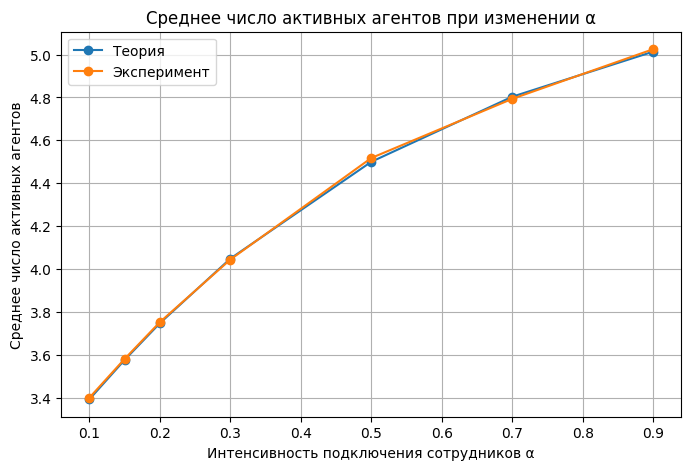

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(alpha_values, active_agents_theory_list, marker='o', label='Теория')
plt.plot(alpha_values, active_agents_exp_list, marker='o', label='Эксперимент')
plt.xlabel('Интенсивность подключения сотрудников α')
plt.ylabel('Среднее число активных агентов')
plt.title('Среднее число активных агентов при изменении α')
plt.legend()
plt.grid(True)
plt.show()

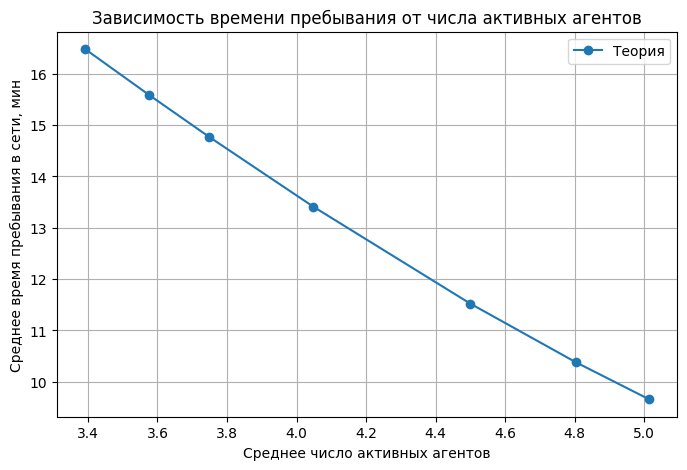

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(active_agents_theory_list, W_theory_list, marker='o', label='Теория')
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Среднее время пребывания в сети, мин')
plt.title('Зависимость времени пребывания от числа активных агентов')
plt.legend()
plt.grid(True)
plt.show()

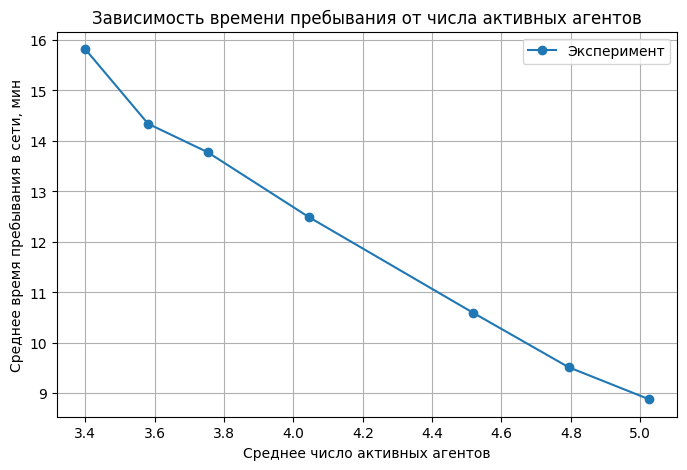

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(active_agents_exp_list, W_exp_list, marker='o', label='Эксперимент')
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Среднее время пребывания в сети, мин')
plt.title('Зависимость времени пребывания от числа активных агентов')
plt.legend()
plt.grid(True)
plt.show()

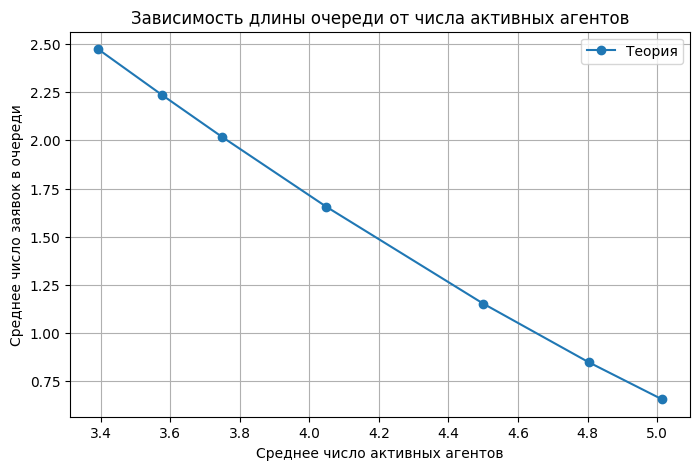

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(active_agents_theory_list, Q_theory_list, marker='o', label='Теория')
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Среднее число заявок в очереди')
plt.title('Зависимость длины очереди от числа активных агентов')
plt.legend()
plt.grid(True)
plt.show()

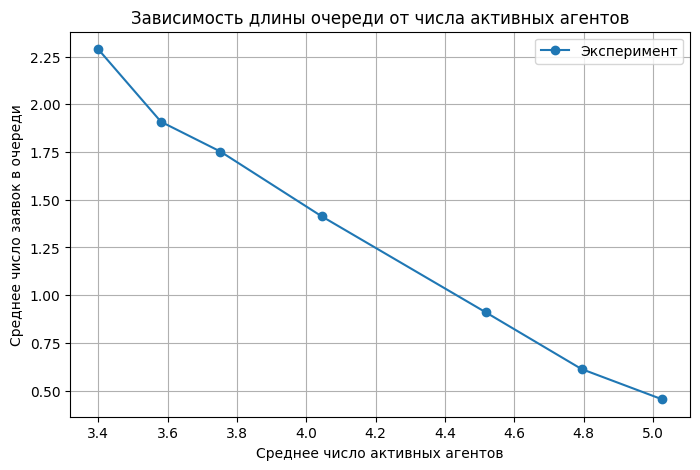

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(active_agents_exp_list, Q_exp_list, marker='o', label='Эксперимент')
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Среднее число заявок в очереди')
plt.title('Зависимость длины очереди от числа активных агентов')
plt.legend()
plt.grid(True)
plt.show()

## 10. Совместное влияние входящего потока и отключения агентов

В этом эксперименте одновременно рассматриваются два фактора:

1. интенсивность входящего потока заявок $\lambda$;
2. интенсивность отключения агентов $\beta$.

Интенсивность подключения сотрудников фиксируется:

$$
\alpha = 0.9.
$$

Для нескольких значений $\beta$ строится зависимость среднего времени пребывания заявки в сети от входящего потока $\lambda$.

Такой график показывает, как система реагирует на рост нагрузки при разной частоте отключения сотрудников.


In [16]:
lambda_values = np.arange(10, 21, 2)
beta_values = [0.3, 0.5, 0.7]

joint_results = []

for current_beta in beta_values:
    for current_lambda in lambda_values:
        exp = run_experiment_avg(
            lambda_clients=current_lambda,
            mu_service=mu_service,
            p_transfer=p_transfer,
            node1_min_agents=node1_min_agents,
            node1_max_agents=node1_max_agents,
            node2_min_agents=node2_min_agents,
            node2_max_agents=node2_max_agents,
            alpha=base_alpha,
            beta=current_beta,
            T=T,
            n_runs=n_runs,
            base_seed=4000 + int(current_lambda * 10) + int(current_beta * 100)
        )

        joint_results.append({
            'λ': current_lambda,
            'β': current_beta,
            'Среднее число активных агентов': exp['active_agents_exp'],
            'W сети, мин': exp['W_network_exp'] * 60,
            'Q': exp['Q_exp']
        })

df_joint = pd.DataFrame(joint_results)
df_joint

,λ,β,Среднее число активных агентов,"W сети, мин",Q
0,10,0.3,5.3570,7.493801,0.0518
1,12,0.3,5.3397,7.674692,0.0993
2,14,0.3,5.3476,7.949961,0.1837
3,16,0.3,5.3680,8.148704,0.2686
4,18,0.3,5.3592,8.815638,0.4971
5,20,0.3,5.3757,9.414129,0.7524
6,10,0.5,4.9890,7.667866,0.0814
7,12,0.5,4.9806,8.040411,0.1610
8,14,0.5,5.0090,8.374771,0.2729
9,16,0.5,5.0046,9.089375,0.5029


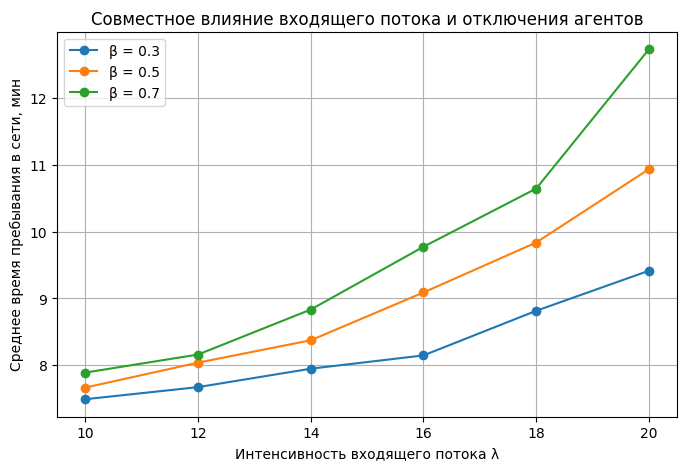

In [17]:
plt.figure(figsize=(8, 5))

for current_beta in beta_values:
    subset = df_joint[df_joint['β'] == current_beta]
    plt.plot(
        subset['λ'],
        subset['W сети, мин'],
        marker='o',
        label=f'β = {current_beta}'
    )

plt.xlabel('Интенсивность входящего потока λ')
plt.ylabel('Среднее время пребывания в сети, мин')
plt.title('Совместное влияние входящего потока и отключения агентов')
plt.legend()
plt.grid(True)
plt.show()

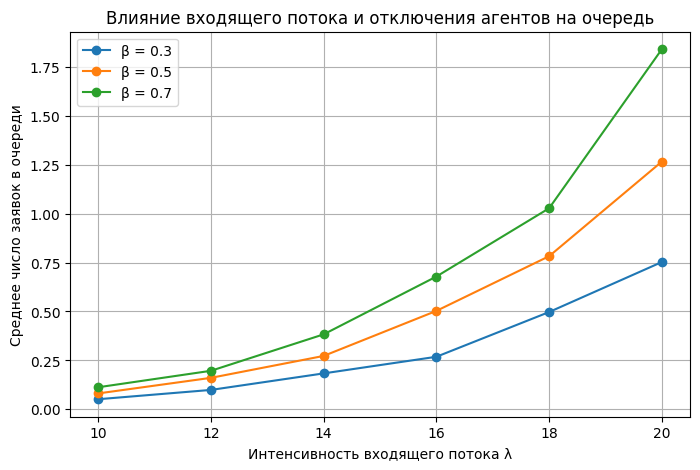

In [18]:
plt.figure(figsize=(8, 5))

for current_beta in beta_values:
    subset = df_joint[df_joint['β'] == current_beta]
    plt.plot(
        subset['λ'],
        subset['Q'],
        marker='o',
        label=f'β = {current_beta}'
    )

plt.xlabel('Интенсивность входящего потока λ')
plt.ylabel('Среднее число заявок в очереди')
plt.title('Влияние входящего потока и отключения агентов на очередь')
plt.legend()
plt.grid(True)
plt.show()

## 11. Анализ результатов

По результатам экспериментов можно сделать следующие выводы:

1. При увеличении интенсивности подключения сотрудников $\alpha$ среднее число активных агентов растёт.
2. Чем больше среднее число активных агентов, тем меньше среднее время пребывания заявки в сети.
3. При увеличении числа активных агентов уменьшается среднее число заявок в очереди.
4. Теоретические и экспериментальные значения имеют одинаковую тенденцию, но могут немного отличаться из-за случайного характера имитационного моделирования.
5. Вероятность потери заявок равна нулю, так как в модели используется неограниченная очередь.
6. Совместный эксперимент показал, что при росте входящего потока $\lambda$ среднее время пребывания и очередь увеличиваются, особенно при высокой интенсивности отключения агентов $\beta$.


## 12. Вывод

В ходе практической работы была построена модель сети массового обслуживания на примере ПВЗ.

Модель включает:
- два узла обслуживания;
- собственную очередь и собственных агентов для каждого узла;
- переход клиентов из первого узла во второй с заданной вероятностью;
- динамическое подключение и отключение сотрудников;
- расчёт показателей, указанных в ТЗ.

Основной вывод: увеличение среднего числа активных сотрудников повышает эффективность сети, а рост входящего потока при частых отключениях агентов ухудшает показатели системы.  
При большем числе активных агентов уменьшаются среднее время пребывания заявки в сети и среднее число заявок в очереди.

Рекомендации:
1. увеличивать интенсивность подключения сотрудников при росте входящего потока;
2. снижать частоту отключений сотрудников при увеличении очереди;
3. отдельно контролировать загрузку узла выдачи заказов и узла дополнительных операций;
4. распределять сотрудников между узлами в зависимости от фактической нагрузки.
